In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2341, 211)
X_test shape: (586, 211)


In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print("Model trained")

Model trained


Linear Regression is essentially a machine learning algorithm used to find the best-fitting line through a scatter plot of data points to help make predictions

In [9]:
y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Baseline")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

Linear Regression Baseline
RMSE: 0.0985
MAE:  0.0737
R²:   0.9460


RMSE = Root mean Squared Error (Used to measure the difference between the predicted values by the model, and the actual values)
MAE = it is a standard metric used to evaluate regression models. It calculates the average magnitude of errors between predicted and actual values.
R^2 = it is another metric used in regression models used to indicate the proportion of variance in the target variable that the model explains (from 0% - 100%, the higher the percentage, the better the model predictions)

In [10]:
y_pred_dollars = np.expm1(y_pred)
y_test_dollars = np.expm1(y_test)

rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
mae_dollars = mean_absolute_error(y_test_dollars, y_pred_dollars)

print(f"In actual dollars:")
print(f"RMSE: ${rmse_dollars:,.0f}")
print(f"MAE:  ${mae_dollars:,.0f}")

In actual dollars:
RMSE: $18,414
MAE:  $12,999


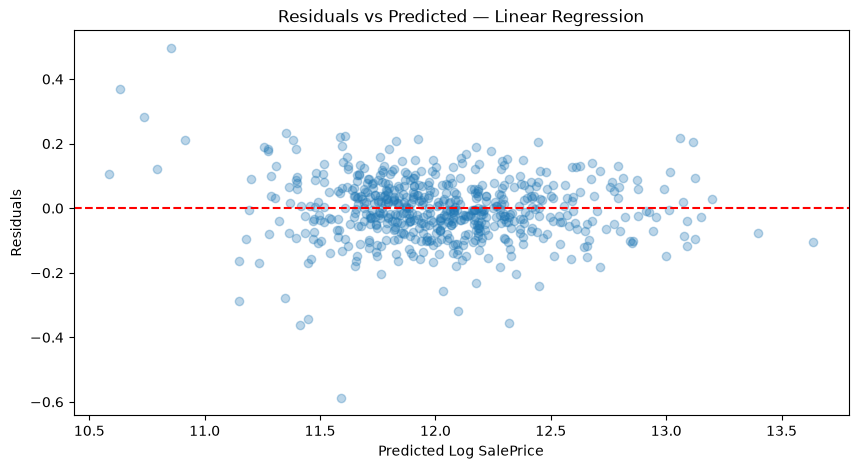

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted — Linear Regression')
plt.show()

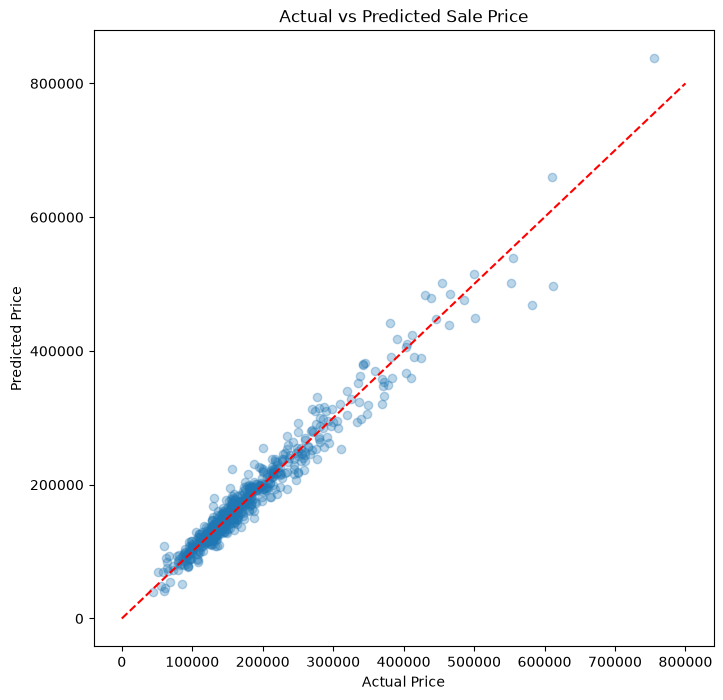

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_dollars, y_pred_dollars, alpha=0.3)
plt.plot([0, 800000], [0, 800000], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Sale Price')
plt.show()

## Baseline Results — Linear Regression

| Metric | Log Scale | Dollar Scale |
|--------|-----------|--------------|
| RMSE   | 0.0985    | $18,414      |
| MAE    | 0.0737    | $12,999      |
| R²     | 0.9460    | —            |

Strong baseline. R² of 0.946 means the model explains 94.6% of price 
variance